# **Aprendizado de Máquina** <BR> **Aula 05** - Classificação multiclasse e classificador *KNN*

# **Exercício 1**. Classificação por classificador *KNN* no *dataset Iris*.

## **1)** Importação de bibliotecas e classes

In [1]:
# Bibliotecas de cálculo, manipulação de dados e geração de gráficos
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [28]:
# Bibliotecas específicas de Machine Learning
#from sklearn.linear_model import LogisticRegression   # Classificador por regressão logística
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split  # Divisão de dados para validação cruzada hold-out
from sklearn.model_selection import cross_val_score   # Validação cruzada k-folds

from sklearn.metrics import accuracy_score, classification_report   # Métricas de qualidade
from sklearn.metrics import ConfusionMatrixDisplay    # Visualização "gráfica" da matriz de confusão

from sklearn.model_selection import GridSearchCV # Importação da biblioteca necessária para a busca em grade (Grid Search)

## **2)** Leitura de dados e exploração inicial

In [4]:
# Leitura do arquivo de dados e exibição do DataFrame
# ATENÇÃO: "monte" o disco e ajuste o caminho do arquivo de dados!
caminho_arquivo = "/content/drive/MyDrive/Colab Notebooks/Ciência de Dados e Inteligência Artificial/Aprendizado de Maquina/Datasets/A05EXEMPLO1_iris.csv"

df = pd.read_csv(caminho_arquivo)
display(df)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,Virginica
146,6.3,2.5,5.0,1.9,2,Virginica
147,6.5,3.0,5.2,2.0,2,Virginica
148,6.2,3.4,5.4,2.3,2,Virginica


### **2.1)** Características gerais

In [5]:
# Contagem de classes da resposta/target
df['species'].value_counts()

,count
species,
Setosa,50
Versicolor,50
Virginica,50


### **2.2)** Gráficos

In [6]:
# Opção usando a biblioteca Seaborn
import seaborn as sns

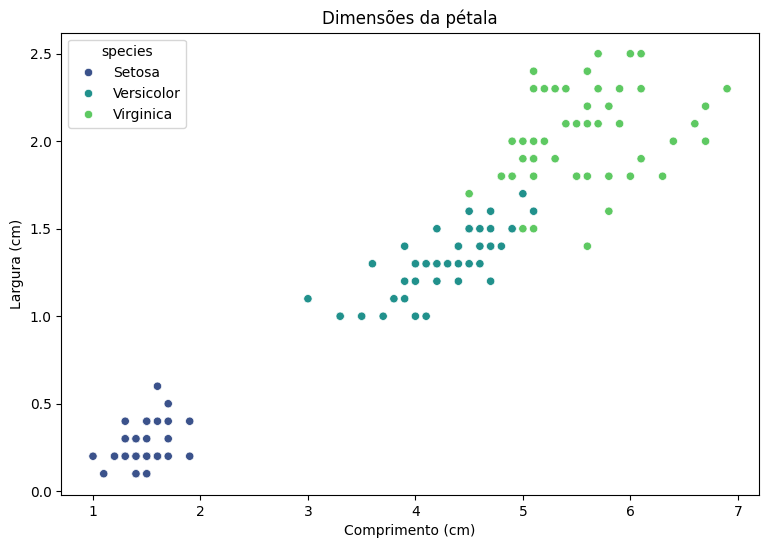

In [7]:
# Diagrama de dispersão entre comprimento e largura da pétala
# Ajustes da figura
# Tamanho do gráfico (polegadas): largura = 9, altura = 6
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da pétala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'petal length (cm)', y = 'petal width (cm)',
                palette = 'viridis', hue = 'species')
plt.show()

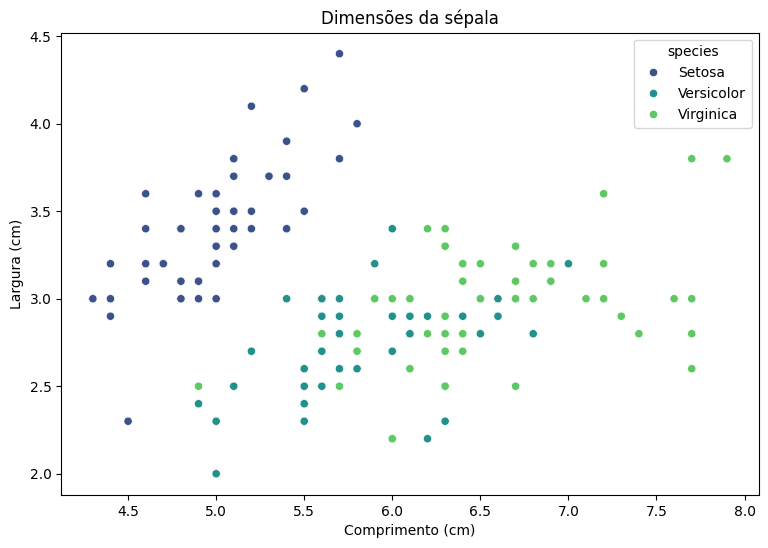

In [8]:
plt.figure(figsize = (9,6))

# Título e rótulos dos eixos
plt.title("Dimensões da sépala")
plt.xlabel("Comprimento (cm)")
plt.ylabel("Largura (cm)")

sns.scatterplot(data = df, x = 'sepal length (cm)', y = 'sepal width (cm)',
                palette = 'viridis', hue = 'species')
plt.show()

## **3)** Seleção e pré-processamento de atributos

In [9]:
X = df.drop(columns = ['target','species'])   # Atributos: 4 dimensões das flores
y = df['species']                             # Reposta: espécie. Opção: df['target']

In [10]:
# Pré-processamento 1: divisão em dados de treino (80%) e teste (20%)
# IMPORTANTE: sem o controle do parâmetro 'random_state', diferentes partições
# do conjunto de dados serão retornadas a cada execução da função de divisão
# o stratify divide igualmente as classes de treino e teste
X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,train_size = 0.8,
                                                        random_state = 42,
                                                        stratify = y)

In [11]:
# Pré-processamento 2: PADRONIZAÇÃO dos atributos (treino e
# teste) segundo a média e desvio padrão DO CONJUNTO DE TREINO

# Importação da biblioteca de padronização de atributos
from sklearn.preprocessing import StandardScaler

# Criação de instância e treinamento de um objeto "escalonador"
escalonador = StandardScaler()
escalonador.fit(X_treino)

# Padronização dos dados de treino e teste
X_treino_Padr = escalonador.transform(X_treino)
X_teste_Padr = escalonador.transform(X_teste)

In [12]:
# Conversão dos conjuntos padronizados em DataFrames
X_treino_Padr = pd.DataFrame(data = X_treino_Padr,columns = X_treino.columns)
X_teste_Padr = pd.DataFrame(data = X_teste_Padr,columns = X_treino.columns)

## **Exercício 1)** Treine um classificardor *KNN* (use K=5) para o dataset Iris e avalie sua qualidade de classificação



## **4)** Treinamento do classificador *KNN*

In [13]:
# Treinamento do classificador com os dados padronizados
clf_KNN = KNeighborsClassifier(n_neighbors=5)
clf_KNN.fit(X_treino_Padr,y_treino)

KNeighborsClassifier()

## **5)** Validação cruzada *hold-out*

In [14]:
# Cálculo das classificações previstas usando os dados de teste
y_previsto = clf_KNN.predict(X_teste_Padr)

# Cálculo da acurácia (nos dados de teste)
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_previsto))

Acurácia = 0.9333333333333333


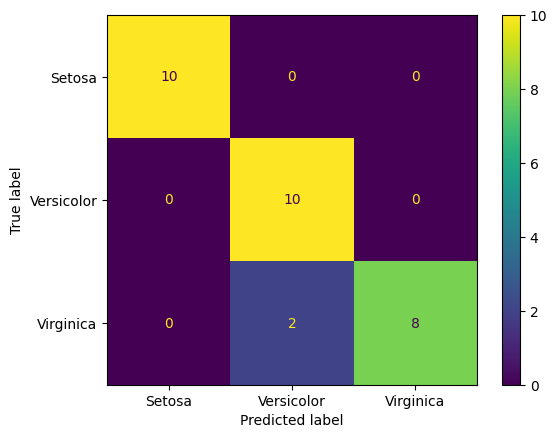

In [15]:
# Representação "gráfica" da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_previsto)
plt.show()

In [16]:
# Relatório das métricas de qualidade
print(classification_report(y_true = y_teste,y_pred = y_previsto,digits = 4))

              precision    recall  f1-score   support

      Setosa     1.0000    1.0000    1.0000        10
  Versicolor     0.8333    1.0000    0.9091        10
   Virginica     1.0000    0.8000    0.8889        10

    accuracy                         0.9333        30
   macro avg     0.9444    0.9333    0.9327        30
weighted avg     0.9444    0.9333    0.9327        30



## **6)** Validação cruzada *k-folds*

In [17]:
# Validação cruzada k-folds (com k = 10), avaliando a ACURÁCIA
# Padronização do conjunto COMPLETO de atributos
X_Padr = escalonador.transform(X)

aval = cross_val_score(clf_KNN,X_Padr,y,cv = 10,scoring = 'accuracy')
M = aval.mean()     # Média das avaliações
DP = aval.std()     # Desvio padrão das avaliações
CV_aval = 100*DP/M  # Coeficiente de variação (%) das avaliações

print("Acurácias obtidas:",aval)
print("")   # "Imprime" uma linha em branco
print("Acurácia média =",M)
print("Coeficiente de variação (%) =",CV_aval)

Acurácias obtidas: [1.         0.93333333 1.         0.93333333 0.86666667 0.93333333
 0.86666667 1.         1.         1.        ]

Acurácia média = 0.9533333333333334
Coeficiente de variação (%) = 5.461713060074582


## **Exercício 2)** Avalie a influência do valor K na acurácia do classificador do Exercício 1, variando o número de vizinhos de 2 a 10

In [41]:
# Treinamento do classificador com os dados padronizados
clf_KNN = KNeighborsClassifier(n_neighbors=10)
clf_KNN.fit(X_treino_Padr,y_treino)

KNeighborsClassifier(n_neighbors=10)

In [42]:
# Cálculo das classificações previstas usando os dados de teste
y_previsto = clf_KNN.predict(X_teste_Padr)

# Cálculo da acurácia (nos dados de teste)
print("Acurácia =",accuracy_score(y_true = y_teste,y_pred = y_previsto))

Acurácia = 0.9666666666666667


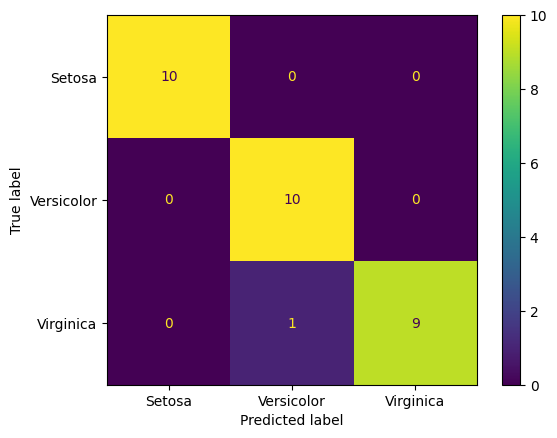

In [43]:
# Representação "gráfica" da matriz de confusão
ConfusionMatrixDisplay.from_predictions(y_true = y_teste,y_pred = y_previsto)
plt.show()

In [21]:
# Relatório das métricas de qualidade
print(classification_report(y_true = y_teste,y_pred = y_previsto,digits = 4))

              precision    recall  f1-score   support

      Setosa     1.0000    1.0000    1.0000        10
  Versicolor     0.9091    1.0000    0.9524        10
   Virginica     1.0000    0.9000    0.9474        10

    accuracy                         0.9667        30
   macro avg     0.9697    0.9667    0.9666        30
weighted avg     0.9697    0.9667    0.9666        30



In [22]:
# Validação cruzada k-folds (com k = 10), avaliando a ACURÁCIA
# Padronização do conjunto COMPLETO de atributos
X_Padr = escalonador.transform(X)

aval = cross_val_score(clf_KNN,X_Padr,y,cv = 10,scoring = 'accuracy')
M = aval.mean()     # Média das avaliações
DP = aval.std()     # Desvio padrão das avaliações
CV_aval = 100*DP/M  # Coeficiente de variação (%) das avaliações

print("Acurácias obtidas:",aval)
print("")   # "Imprime" uma linha em branco
print("Acurácia média =",M)
print("Coeficiente de variação (%) =",CV_aval)

Acurácias obtidas: [1.         0.93333333 1.         0.93333333 0.93333333 1.
 0.93333333 0.93333333 1.         0.93333333]

Acurácia média = 0.96
Coeficiente de variação (%) = 3.4020690871988575


---
**Fim do Exercícioss 1 e 2 da Aula 05**

## **Exercício extra:** Classificação de uma flor "Inédita"

In [23]:
# Recordando os nomes dos atributos
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target', 'species'],
      dtype='object')

In [24]:
# Criação de dicionário de provisão
X_prev = {'sepal length (cm)':[5.0, 7.2],
          'sepal width (cm)':[3.6, 3.5],
          'petal length (cm)':[1.4, 4.1],
          'petal width (cm)':[0.2, 2.3]}
          # 7.2, 3.5, 4.1, 2.3

In [25]:
# Converter dicionário e dataframe
X_prev = pd.DataFrame(data = X_prev)
X_prev

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.0,3.6,1.4,0.2
1,7.2,3.5,4.1,2.3


In [26]:
# Padronização do DataFrame de previsão
X_prev_Padr = escalonador.transform(X_prev)
display(X_prev_Padr)

array([[-1.00507713,  1.23511762, -1.34572231, -1.32327558],
       [ 1.62205517,  1.01122923,  0.18737906,  1.44177787]])

In [27]:
# Previsão
y_prev = clf_KNN.predict(X_prev_Padr)
print("Espécie prevista:",y_prev)

Espécie prevista: ['Setosa' 'Virginica']


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


## Busca em grade para o hiperparâmetro K

In [35]:
GradeHP ={'n_neighbors': range(2, 11)} # {'n_neighbors': [1, 2, 3, 4 , 5, 6, 7, 8, 9, 10]}

In [36]:
GradeBusca = GridSearchCV(clf_KNN,param_grid = GradeHP,cv = 10,scoring = 'accuracy')
GradeBusca.fit(X_Padr,y)

GridSearchCV(cv=10, estimator=KNeighborsClassifier(n_neighbors=8),
             param_grid={'n_neighbors': range(2, 11)}, scoring='accuracy')

In [40]:
print("Melhor solução:",GradeBusca.best_estimator_)

print("")   # "Imprime" uma linha em branco
print("Melhor valor de 'k' =",GradeBusca.best_estimator_.n_neighbors)

Melhor solução: KNeighborsClassifier(n_neighbors=8)

Melhor valor de 'k' = 8


In [38]:
# Detalhes da busca: dicionário de resultados convertido em DataFrame
resultados = GradeBusca.cv_results_
df_resultados = pd.DataFrame(data = resultados)
display(df_resultados)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_n_neighbors,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,split5_test_score,split6_test_score,split7_test_score,split8_test_score,split9_test_score,mean_test_score,std_test_score,rank_test_score
0,0.002178,0.001947,0.008129,0.007925,2,{'n_neighbors': 2},1.0,0.933333,1.0,0.933333,0.866667,1.000000,0.800000,1.000000,1.0,1.000000,0.953333,0.066999,6
1,0.001539,0.000124,0.003894,0.000615,3,{'n_neighbors': 3},1.0,0.933333,1.0,0.933333,0.866667,1.000000,0.800000,1.000000,1.0,1.000000,0.953333,0.066999,6
2,0.001625,0.000106,0.004046,0.000249,4,{'n_neighbors': 4},1.0,0.933333,1.0,0.933333,0.933333,1.000000,0.800000,0.933333,1.0,0.933333,0.946667,0.058119,9
3,0.001618,0.000070,0.004175,0.000420,5,{'n_neighbors': 5},1.0,0.933333,1.0,0.933333,0.866667,0.933333,0.866667,1.000000,1.0,1.000000,0.953333,0.052068,6
4,0.001440,0.000244,0.003539,0.000701,6,{'n_neighbors': 6},1.0,0.933333,1.0,0.933333,1.000000,1.000000,0.866667,0.933333,1.0,1.000000,0.966667,0.044721,2
5,0.001334,0.000189,0.003267,0.000548,7,{'n_neighbors': 7},1.0,0.933333,1.0,0.933333,1.000000,0.933333,0.866667,0.933333,1.0,1.000000,0.960000,0.044222,3
6,0.001895,0.000338,0.004291,0.000495,8,{'n_neighbors': 8},1.0,0.933333,1.0,0.933333,1.000000,1.000000,0.933333,0.933333,1.0,1.000000,0.973333,0.032660,1
7,0.001182,0.000080,0.002792,0.000084,9,{'n_neighbors': 9},1.0,0.933333,1.0,0.933333,0.933333,1.000000,0.866667,0.933333,1.0,1.000000,0.960000,0.044222,3
8,0.001172,0.000094,0.002929,0.000306,10,{'n_neighbors': 10},1.0,0.933333,1.0,0.933333,0.933333,1.000000,0.933333,0.933333,1.0,0.933333,0.960000,0.032660,3
